In [2]:
%pip install sdv pandas numpy plt sns

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sdv.metadata import SingleTableMetadata
from scipy.stats import ks_2samp, chi2_contingency

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset de ejemplo oficial
# Este dataset está pre-limpiado para pruebas de síntesis
url_real_data = "../../datasources/bank_full_dataset/bank-full.csv"
df_real = pd.read_csv(url_real_data, sep=';')
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)

print("Columnas del dataset:", df_real.columns.tolist())
df_real.head()

num_cols = df_real.select_dtypes(include=[np.number]).columns
print("Columnas numericas:", num_cols)
cat_cols = df_real.select_dtypes(exclude=[np.number]).columns
print("Columnas categoricas:", cat_cols)

url_synth_data = "distilgpt2_synth_out.csv"
df_synth = pd.read_csv(url_synth_data, sep=',', index_col=0)

Columnas del dataset: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Columnas numericas: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')
Columnas categoricas: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [4]:
# 5. Función de reporte de calidad
def reporte_calidad(real, synth):
    print("\n" + "="*40)
    print("   REPORTE DE FIDELIDAD ESTADÍSTICA")
    print("="*40 + "\n")
      
    # Test de Proporciones para Categóricas (Diferencia Media)
    cat_cols = real.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        f_real = real[col].value_counts(normalize=True).sort_index()
        f_synth = synth[col].value_counts(normalize=True).sort_index()
        diff = (f_real - f_synth).abs().mean()
        status = "✅ FIEL" if diff < 0.05 else "❌ DESVIADO"
        print(f"Prop. Diff [{col:10}]: {diff:.4f} {status}")

reporte_calidad(df_real, df_synth)


   REPORTE DE FIDELIDAD ESTADÍSTICA

Prop. Diff [job       ]: 0.0889 ❌ DESVIADO
Prop. Diff [marital   ]: 0.0910 ❌ DESVIADO
Prop. Diff [education ]: 0.0259 ✅ FIEL
Prop. Diff [default   ]: 0.0330 ✅ FIEL
Prop. Diff [housing   ]: 0.1422 ❌ DESVIADO
Prop. Diff [loan      ]: 0.0540 ❌ DESVIADO
Prop. Diff [contact   ]: 0.1615 ❌ DESVIADO
Prop. Diff [month     ]: 0.0236 ✅ FIEL
Prop. Diff [poutcome  ]: 0.0891 ❌ DESVIADO
Prop. Diff [y         ]: 0.1035 ❌ DESVIADO


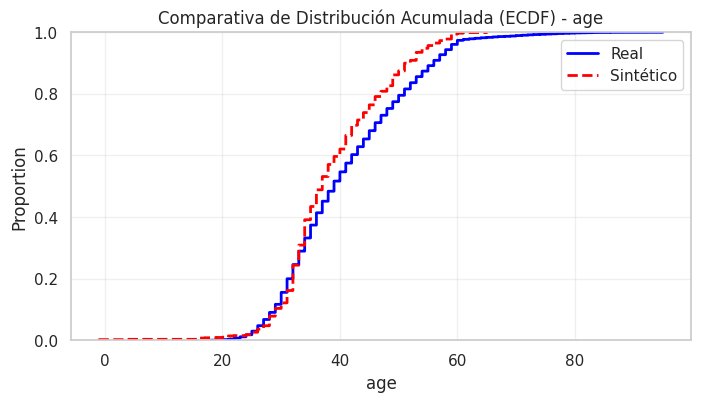

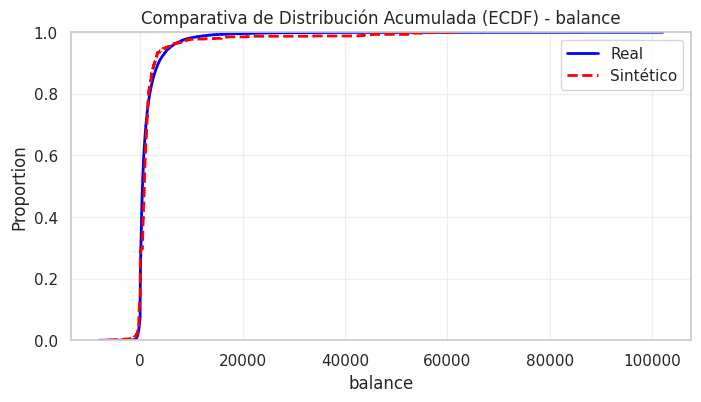

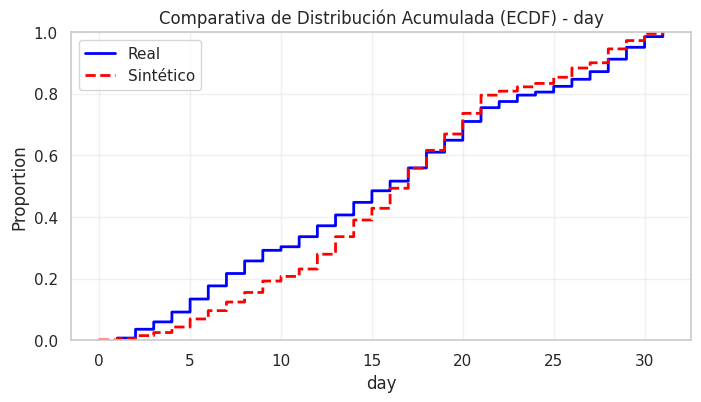

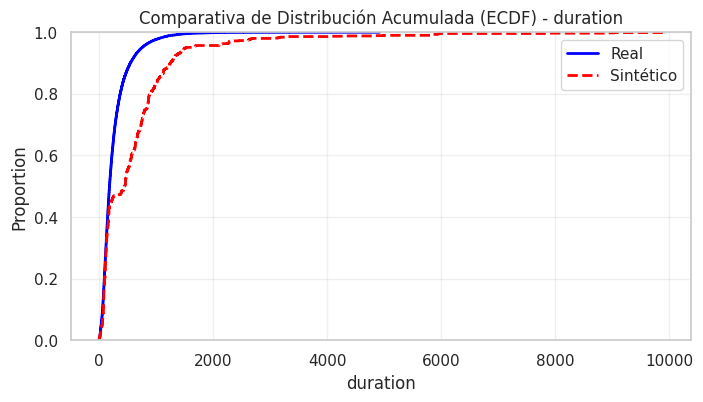

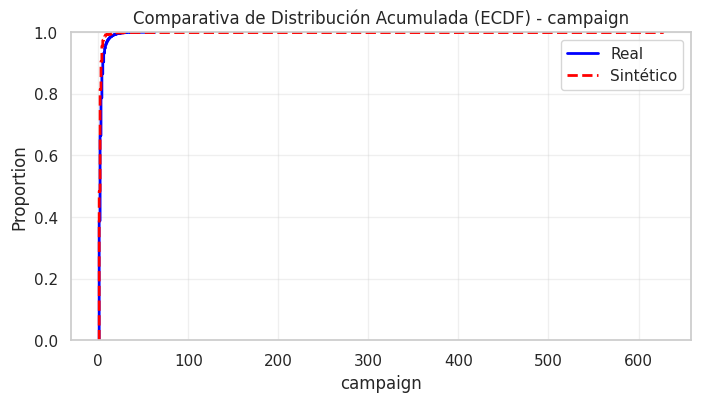

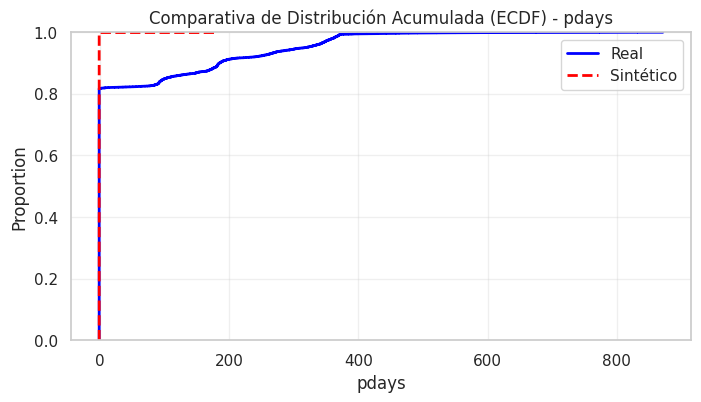

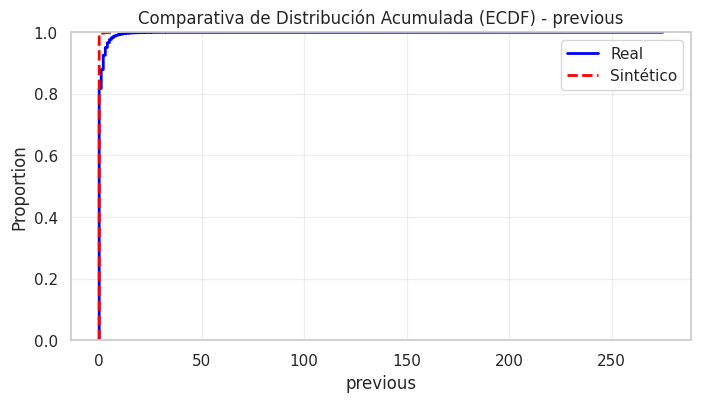

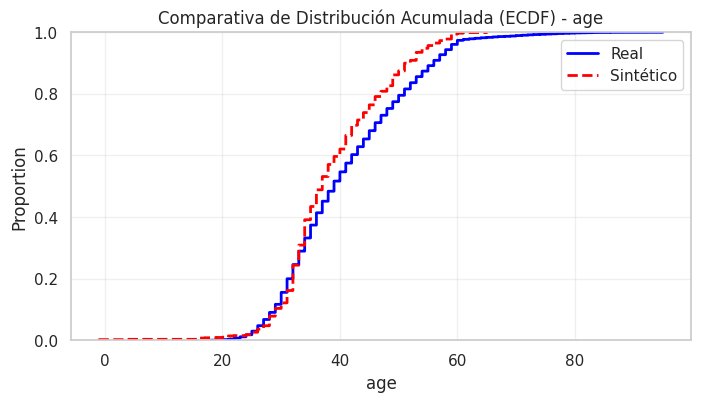

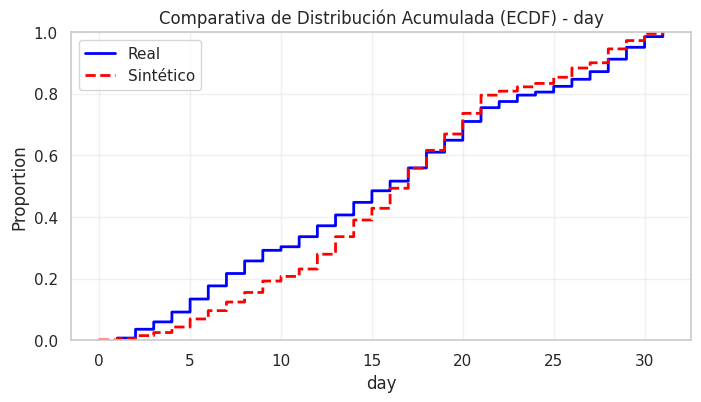

In [5]:
def plot_ks_visual(real, synth, col):
    plt.figure(figsize=(8, 4))
    sns.ecdfplot(real[col], label='Real', color='blue', linewidth=2)
    sns.ecdfplot(synth[col], label='Sintético', color='red', linestyle='dashed', linewidth=2)
    plt.title(f"Comparativa de Distribución Acumulada (ECDF) - {col}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Visualizar la columna más crítica (usualmente balance o age)
for col_critica in num_cols:
    plot_ks_visual(df_real, df_synth, col_critica)

plot_ks_visual(df_real, df_synth, 'age')
plot_ks_visual(df_real, df_synth, 'day')

--- Columna: age ---
Distancia K-S (D): nan
P-valor: nan


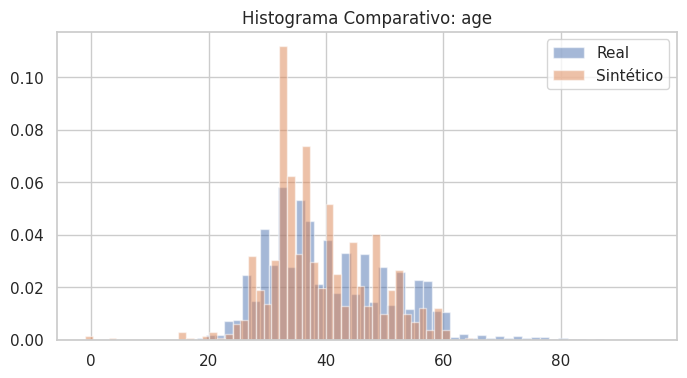

--- Columna: day ---
Distancia K-S (D): nan
P-valor: nan


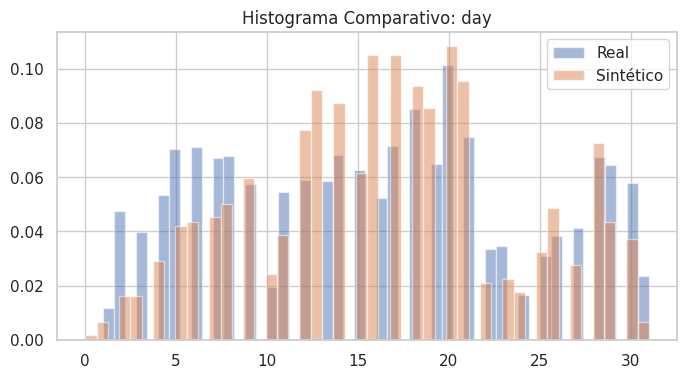

In [6]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

for col in ['age', 'day']:
    d_stat, p_val = ks_2samp(df_real[col], df_synth[col])
    print(f"--- Columna: {col} ---")
    print(f"Distancia K-S (D): {d_stat:.4f}")
    print(f"P-valor: {p_val:.4f}")
    
    # Visualización de la diferencia acumulada
    plt.figure(figsize=(8, 4))
    plt.hist(df_real[col], bins=50, alpha=0.5, label='Real', density=True)
    plt.hist(df_synth[col], bins=50, alpha=0.5, label='Sintético', density=True)
    plt.title(f"Histograma Comparativo: {col}")
    plt.legend()
    plt.show()

In [7]:
from sdv.evaluation.single_table import evaluate_quality
from sdv.evaluation.single_table import get_column_plot

# --- PASO 8: Evaluación de Calidad Global ---
# Compara el dataframe original (df) con el sintético (synthetic_data)
quality_report = evaluate_quality(
    real_data=df_real,
    synthetic_data=df_synth,
    metadata=metadata
)

# Obtenemos las puntuaciones detalladas
print(f"\nScore de Calidad Global: {quality_report.get_score():.2%}")
quality_report.get_details('Column Shapes') # Fidelidad de las distribuciones

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 17/17 [00:00<00:00, 290.45it/s]|
Column Shapes Score: 81.35%

(2/2) Evaluating Column Pair Trends: |██████████| 136/136 [00:00<00:00, 206.71it/s]|
Column Pair Trends Score: 59.85%

Overall Score (Average): 70.6%


Score de Calidad Global: 70.60%


,Column,Metric,Score
0,age,KSComplement,0.904635
1,job,TVComplement,0.500454
2,marital,TVComplement,0.816933
3,education,TVComplement,0.911194
4,default,TVComplement,0.934000
5,balance,KSComplement,0.805283
6,housing,TVComplement,0.813838
7,loan,TVComplement,0.892000
8,contact,TVComplement,0.727741
9,day,KSComplement,0.894941


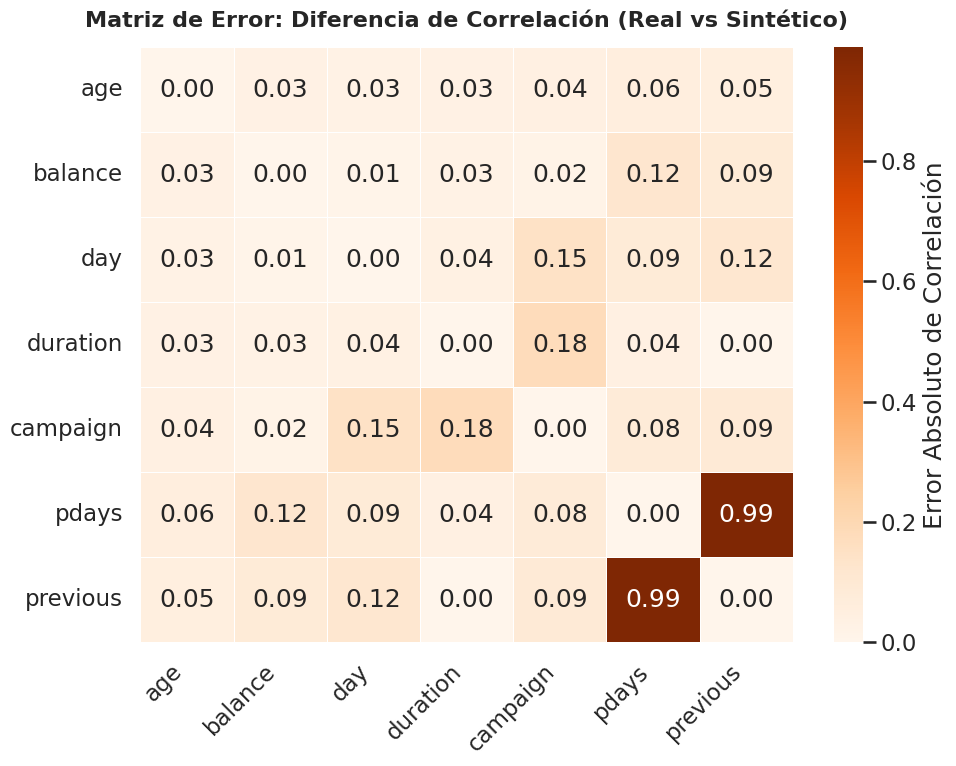

--------------------------------------------------
Resumen de Precisión de Relaciones:
Error Medio Absoluto de Correlación (MAE): 0.1086
--------------------------------------------------
❌ El error es alto. Considera revisar los hiperparámetros o la distribución por defecto.


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Calcular matrices de correlación usando Spearman (ideal para distribuciones no normales)
corr_real = df_real[num_cols].corr(method='spearman')
corr_sintetica = df_synth[num_cols].corr(method='spearman')

# 3. Calcular la diferencia absoluta entre ambas matrices
matriz_diferencia = np.abs(corr_real - corr_sintetica)

# 4. Configurar el estilo visual para presentación
sns.set_context("talk")
plt.figure(figsize=(10, 8))

# Graficamos la matriz de error
sns.heatmap(
    matriz_diferencia, 
    annot=True, 
    cmap="Oranges", 
    fmt=".2f", 
    linewidths=.5,
    cbar_kws={'label': 'Error Absoluto de Correlación'}
)

plt.title("Matriz de Error: Diferencia de Correlación (Real vs Sintético)", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Métrica de resumen: Error Medio Absoluto (MAE) de las correlaciones
# Tomamos solo el triángulo superior para no duplicar los cálculos (la matriz es simétrica)
indices_triu = np.triu_indices_from(matriz_diferencia, k=1)
mae_corr = matriz_diferencia.values[indices_triu].mean()

print("-" * 50)
print(f"Resumen de Precisión de Relaciones:")
print(f"Error Medio Absoluto de Correlación (MAE): {mae_corr:.4f}")
print("-" * 50)

if mae_corr <= 0.05:
    print("El modelo respeta las relaciones de manera óptima.")
elif mae_corr <= 0.10:
    print("Resultado aceptable. Hay ligeras desviaciones en algunas relaciones.")
else:
    print("❌ El error es alto. Considera revisar los hiperparámetros o la distribución por defecto.")

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# 1. Copias de seguridad para no alterar los DataFrames originales
df_real_ml = df_real.copy()
df_syn_ml = df_synth.copy()

# 2. Preprocesamiento: Encodear variables categóricas (necesario para Random Forest)
label_encoders = {}
categorical_cols = df_real_ml.select_dtypes(include=['object']).columns

print(f"check: {df_real_ml.select_dtypes(include=['object']).columns}")

print(f"check: {df_syn_ml.select_dtypes(include=['object']).columns}")

for col in categorical_cols:
    le = LabelEncoder()
    # Entrenamos el encoder únicamente con los datos reales
    df_real_ml[col] = le.fit_transform(df_real_ml[col].astype(str))
    # Transformamos los datos sintéticos con el mismo criterio
    df_syn_ml[col] = le.transform(df_syn_ml[col].astype(str))

# 3. Separar Variables Predictoras (X) y Objetivo (y)
X_real = df_real_ml.drop(columns=['y'])
y_real = df_real_ml['y']

X_syn = df_syn_ml.drop(columns=['y'])
y_syn = df_syn_ml['y']

# 4. Dividir el dataset REAL en entrenamiento y prueba
# Reservamos un 20% de datos reales puros para la evaluación final de ambos modelos
X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

# --- MODELO A: Entrenado con Datos Reales ---
model_real = RandomForestClassifier(random_state=42, n_estimators=100)
model_real.fit(X_real_train, y_real_train)

y_pred_real = model_real.predict(X_real_test)
y_proba_real = model_real.predict_proba(X_real_test)[:, 1]

# --- MODELO B: Entrenado con Datos Sintéticos ---
model_syn = RandomForestClassifier(random_state=42, n_estimators=100)
# Entrenamos con TODOS los datos sintéticos generados
model_syn.fit(X_syn, y_syn)

y_pred_syn = model_syn.predict(X_real_test)
y_proba_syn = model_syn.predict_proba(X_real_test)[:, 1]

# 5. Reporte Comparativo de Resultados
print("=" * 60)
print("📊 RESULTADOS DE MACHINE LEARNING EFFICACY")
print("=" * 60)

roc_real = roc_auc_score(y_real_test, y_proba_real)
roc_syn = roc_auc_score(y_real_test, y_proba_syn)

print(f"🏆 ROC AUC [Modelo entrenado con Datos Reales]:    {roc_real:.4f}")
print(f"🎭 ROC AUC [Modelo entrenado con Datos Sintéticos]: {roc_syn:.4f}")
print("-" * 60)

# Calculamos la retención de la capacidad predictiva
retencion_eficacia = (roc_syn / roc_real) * 100
print(f"La calidad de tus datos sintéticos retiene el {retencion_eficacia:.2f}% de la capacidad predictiva.")
print("=" * 60)

print("\n📋 Detalle de Clasificación (Modelo Sintético evaluando Datos Reales):")
print(classification_report(y_real_test, y_pred_syn))

check: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')
check: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


ValueError: y contains previously unseen labels: 'blue-collar, balance is 867'

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import pairwise_distances
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Preprocesamiento homogéneo para medir distancias reales
# Para que la distancia sea justa, normalizamos los números y encodeamos las categorías
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

# Tomamos una muestra para agilizar el cálculo de distancias (las matrices grandes saturan la RAM)
n_muestras = min(20000, len(df_real), len(df_synth))
df_real_sample = df_real.sample(n=n_muestras, random_state=42)
df_syn_sample = df_synth.sample(n=n_muestras, random_state=42)

# Ajustamos el preprocesador solo con los datos reales y transformamos ambos
X_real_transformed = preprocessor.fit_transform(df_real_sample)
X_syn_transformed = preprocessor.transform(df_syn_sample)

# 3. Calcular la matriz de distancias euclidianas entre sintéticos y reales
# Cada fila representará un registro sintético y cada columna un registro real
distancias = pairwise_distances(X_syn_transformed, X_real_transformed, metric='euclidean')

# 4. Encontrar la distancia al registro real más cercano para cada registro sintético
# Esto representa la "Similitud Máxima"
distancia_minima_por_registro = np.min(distancias, axis=1)

# 5. Visualización de la distribución de distancias mínimas
plt.figure(figsize=(10, 6))
sns.set_context("talk")
sns.histplot(distancia_minima_por_registro, bins=30, kde=True, color="purple")

plt.axvline(x=0.1, color='red', linestyle='--', label='Zona de riesgo de copia (< 0.1)')
plt.title("Distribución de la Distancia al Registro Real más Cercano", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Distancia Mínima (A menor distancia, mayor similitud)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Reporte de Resultados
proporcion_identicos = np.mean(distancia_minima_por_registro < 0.1) * 100

print("=" * 60)
print("🛡️ REPORTE DE SIMILITUD MÁXIMA Y PRIVACIDAD")
print("=" * 60)
print(f"Distancia mínima promedio general: {distancia_minima_por_registro.mean():.4f}")
print(f"Distancia mínima absoluta encontrada: {distancia_minima_por_registro.min():.4f}")
print(f"Porcentaje de datos sintéticos casi idénticos a los reales: {proporcion_identicos:.4f}%")
print("=" * 60)

if proporcion_identicos > 1.0:
    print("❌ Alerta: El modelo está memorizando demasiados datos reales. Reduce las épocas o simplifica el modelo.")
elif distancia_minima_por_registro.mean() > 5.0:
    print("⚠️ Alerta: Los datos sintéticos están demasiado lejos de los reales. El modelo no está capturando bien la densidad.")
else:
    print("✅ ¡Excelente balance! El modelo genera datos nuevos sin copiar idénticamente los registros reales.")